# Skjønnlitteratur read pickle

Korpus - fra BBI-prosjekt

Lars G. Bagøien Johnsen

Kristin Ørjasæter

In [141]:
import dhlab as dh
import pandas as pd
import numpy as np

# Henter korpuset 

In [142]:
import dhlab as dh
import dhlab.api.dhlab_api as api
import pandas as pd
#import dhlab.graph_networkx_louvain as gnl
import networkx as nx
import requests
import json
from io import StringIO



def sim_words(word=None, limit=10, collection_name='vss_1950-2015_cos'):
    params = locals()
    r = requests.get(f"{dh.constants.BASE_URL}/similarity/sim_words", params=params)

    if r.status_code != 200:
        return pd.DataFrame(columns=["word", "score"])

    return pd.DataFrame(r.json(), columns=["word", "score"])


In [143]:
corpus = pd.read_csv("barn.csv", index_col=0, low_memory=False).fillna('')

In [119]:
corpus.groupby(["year", "publisher"]).size()

year    publisher                                                                                                   
1945.0  Ansgar                                                                                                           3
        Ansgar forlag                                                                                                    1
        Aschehoug                                                                                                       17
        Børrehaug & Remen                                                                                                1
        Cammermeyer                                                                                                      3
                                                                                                                        ..
2024.0  Gyldendal                                                                                                       10
        Institutt for 

In [3]:
corpus.head(5)

,dhlabid,urn,lenker,title,authors,oaiid,city,year,publisher,langs,...,ddc,genres,literaryform,kristin,sesamid,isbn10,timestamp,doctype,ocr_creator,ocr_timestamp
78,100289681,URN:NBN:no-nb_digibok_2016041448047,Vis element,Eventyret om fanden i nøtten,"Asbjørnsen , Peter Christen / Moe , Jørgen / M...",,Oslo,1945.0,Damm,nob,...,,,Skjønn,Skjønn,,,,,,
59,100213176,URN:NBN:no-nb_digibok_2014071508018,Vis element,Farlig spill : en guttefortelling,"Ask , Espen / Brandvold , Åshild",,Oslo,1945.0,Ekko,nob,...,,,Skjønn,Skjønn,,,,,,
117,100309755,URN:NBN:no-nb_digibok_2016090948102,Vis element,Finnmarks-Ravna,"Ott , Estrid / Treider , Esther Normann . / Gj...",,Oslo,1945.0,Gyldendal,nob / dan,...,,fiction,Skjønnlitteratur,,,,,,,
17,100226008,URN:NBN:no-nb_digibok_2014091708167,Vis element,Flagg over Vangen : forteljing om Vangsgutane,"Halse , Leif / Nilssen , Jens R.",,Oslo,1945.0,Fonna,nno,...,,,Skjønn,Skjønn,,,,,,
24,100572774,URN:NBN:no-nb_digibok_2007011200043,Vis element,Fra 9. april til 7. juni : episoder og oplevel...,"Gotaas , Birger",,,1945.0,Dybwad,nob,...,948.1053,,Fag,Fag,,,,,,


## Går videre med skjønnlitteratur

In [4]:
c = corpus[corpus.literaryform.str.contains("jønn")]

In [5]:
c.head(5)

,dhlabid,urn,lenker,title,authors,oaiid,city,year,publisher,langs,...,ddc,genres,literaryform,kristin,sesamid,isbn10,timestamp,doctype,ocr_creator,ocr_timestamp
78,100289681,URN:NBN:no-nb_digibok_2016041448047,Vis element,Eventyret om fanden i nøtten,"Asbjørnsen , Peter Christen / Moe , Jørgen / M...",,Oslo,1945.0,Damm,nob,...,,,Skjønn,Skjønn,,,,,,
59,100213176,URN:NBN:no-nb_digibok_2014071508018,Vis element,Farlig spill : en guttefortelling,"Ask , Espen / Brandvold , Åshild",,Oslo,1945.0,Ekko,nob,...,,,Skjønn,Skjønn,,,,,,
117,100309755,URN:NBN:no-nb_digibok_2016090948102,Vis element,Finnmarks-Ravna,"Ott , Estrid / Treider , Esther Normann . / Gj...",,Oslo,1945.0,Gyldendal,nob / dan,...,,fiction,Skjønnlitteratur,,,,,,,
17,100226008,URN:NBN:no-nb_digibok_2014091708167,Vis element,Flagg over Vangen : forteljing om Vangsgutane,"Halse , Leif / Nilssen , Jens R.",,Oslo,1945.0,Fonna,nno,...,,,Skjønn,Skjønn,,,,,,
85,100323133,URN:NBN:no-nb_digibok_2017012748140,Vis element,Full fart forover,"Bauer , Lill Herlofson",,Oslo,1945.0,Aschehoug,nob,...,,,Skjønn,Skjønn,,,,,,


In [135]:
utgaver = c[c.year >=2005].groupby(["year"]).size()

In [136]:
utgaver.sort_values(ascending=False)

year
2012.0    863
2018.0    853
2011.0    838
2017.0    833
2008.0    831
2014.0    822
2013.0    803
2006.0    797
2016.0    788
2007.0    776
2015.0    769
2005.0    757
2010.0    754
2009.0    736
2019.0    629
2020.0    273
2021.0    156
2022.0     89
2024.0     30
2023.0     26
dtype: int64

# Ordgrupper og kategorier

In [6]:
word_groups = {
  "funksjonsnedsettelse": [
    "handikappet", "funksjonshemmet", "blind", "svaksynt",
    "døv", "tunghørt", "hørselshemmet",
    "klumpfot", "albino",
    "rullestolbruker", "bevegelseshemmet",
    "psykisk utviklingshemmet", "autistisk", "autisme",
    "dyslektiker", "epileptiker"
  ],

  "utseende_kropp": [
    "tykk", "tynn", "høy", "lav", "kraftig", "overvektig",
    "undervektig"
  ],

  "seksuell_legning_kjønn": [
    "trans", "transe", "transkjønnet",
    "homofil", "homse",
    "lesbisk", "lesbe",
    "bi", "bifil",
    "panfil", "aseksuell", "queer"
  ],

  "egennavn": [
    "fornavn", "etternavn", "personnavn", "stedsnavn"
  ],

  "nasjonalitet": [
    "pakistansk", "arabisk", "afrikansk", "grønlender", "grønlandsk",
    "islandsk", "polsk", "russer", "russisk", "amerikaner",
    "hindu", "japaner", "asiat", "kineser", "tysker", "franskmann",
    "britisk", "engelsk", "svensk", "dansk", "finsk",
    "norsk", "samisk", "litauer", "ukrainer", "spanjol", "italiener",
    "portugiser"
  ],

  "geografi": [
    "norden", "europa", "asia", "amerika", "afrika",
    "australia", "antarktis", "arktis", "ural",
    "balkan", "kaukasus", "midtøsten", "skandinavia"
  ],

  "språk": [
    "engelsk", "pakistansk", "urdu",
    "svensk", "dansk", "finsk", "islandsk", "grønlandsk", "samisk",
    "fransk", "tysk", "polsk", "litauisk", "russisk",
    "italiensk", "spansk", "castillano", "portugisisk",
    "kinesisk", "japansk", "tamil", "arabisk", "swahili",
    "norsk", "nynorsk", "bokmål", "latin",
    "gresk", "hebraisk", "persisk", "kurdisk"
  ],

  "religion": [
    "kristendom", "hinduisme", "islam", "muhammedanisme",
    "taoisme", "jødedom", "koptisk", "katolisisme",
    "protestantisme", "ortodoksi", "buddhisme", "sikhisme"
  ],

  "kultur_markorer": [
    "urfolk", "indianer", "araber", "afrikaner",
    "amerikaner", "europeer", "nordisk", "samisk",
    "romfolk", "sinti", "keltisk",
    "innvandrer", "minoritet"
  ]
}

In [7]:
words = [x for y in word_groups for x in word_groups[y]]

In [8]:
mapping = {x:y for y in word_groups for x in word_groups[y]}
    

# Teller alle ordene

In [9]:
#counts = dh.Counts(corpus = urns, words = words)

In [146]:
totcounts = dh.Counts(corpus = c.urn.to_list(), words = [".", ",","og"])

In [150]:
totcounts.frame.T.sum().sum()

np.float64(107438337.0)

In [10]:
#counts = counts.frame

In [11]:
counts = pd.read_pickle("skjønnlitteratur.pkl")

# Legger gruppene til datarammen

In [12]:
counts["group"] = counts.index.map(lambda w: mapping.get(w, None))

In [13]:
counts.head(5)

urn,100000334,100000453,100001357,100001359,100001386,100001460,100001463,100001486,100001505,100001620,...,100713808,100713851,100713863,100714106,100714471,100715960,100716135,100716271,100721728,group
word,,,,,,,,,,,,,,,,,,,,,
afrika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi
afrikaner,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kultur_markorer
afrikansk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nasjonalitet
albino,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,funksjonsnedsettelse
amerika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi


# Utfører telling og normalisering

In [14]:
# anta:
# counts: index = ord
#         kolonner = dhlabid ... + 'group'
# years_df: kolonner ['dhlabid', 'year']

# 0: lag en ren years-Series med unik index
years = (
    c
    .drop_duplicates("dhlabid")
    .set_index("dhlabid")["year"]
).dropna().astype(int)

counts.columns = counts.columns.astype(str)
c["dhlabid"] = c["dhlabid"].astype(str)

# 1: dokumentkolonnene i counts (alle unntatt 'group')
doc_cols = counts.columns.drop("group")

# 2: felles dhlabid mellom counts og years
common = doc_cols.intersection(years.index)

# 3: trekk ut bare de dokumentene vi har både counts og år for
X = counts[common]              # ord × dokument
years_valid = years.loc[common] # index = dhlabid, value = år

/tmp/ipykernel_2202582/1963893982.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c["dhlabid"] = c["dhlabid"].astype(str)


In [15]:
# 4: ord × år (summerer alle docs med samme år)
word_by_year = X.groupby(years_valid, axis=1).sum()

# 5: grupper × år
group_by_year = (
    word_by_year
    .assign(group=counts["group"])
    .groupby("group")
    .sum()                      # her forsvinner 'group'-kolonnen, år-kolonner blir igjen
    .sort_index(axis=1)         # sortér år langs kolonne-aksen
)

/tmp/ipykernel_2202582/234373164.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  word_by_year = X.groupby(years_valid, axis=1).sum()


In [16]:
group_by_year

year,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
group,,,,,,,,,,,,,,,,,,,,,
egennavn,13.0,12.0,19.0,16.0,25.0,35.0,14.0,24.0,19.0,21.0,...,129.0,139.0,135.0,96.0,85.0,32.0,13.0,20.0,6.0,5.0
funksjonsnedsettelse,90.0,58.0,72.0,95.0,99.0,138.0,115.0,129.0,93.0,82.0,...,428.0,463.0,329.0,418.0,278.0,91.0,46.0,26.0,10.0,11.0
geografi,0.0,2.0,0.0,2.0,0.0,1.0,1.0,3.0,0.0,0.0,...,5.0,4.0,6.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0
kultur_markorer,116.0,106.0,67.0,58.0,117.0,177.0,120.0,118.0,102.0,146.0,...,136.0,81.0,142.0,109.0,71.0,36.0,7.0,8.0,20.0,2.0
nasjonalitet,64.0,131.0,83.0,90.0,103.0,190.0,72.0,84.0,49.0,80.0,...,175.0,135.0,128.0,107.0,64.0,29.0,42.0,57.0,3.0,0.0
religion,24.0,12.0,4.0,5.0,22.0,11.0,1.0,8.0,20.0,6.0,...,37.0,67.0,81.0,42.0,12.0,7.0,0.0,2.0,0.0,1.0
seksuell_legning_kjønn,30.0,50.0,40.0,38.0,56.0,74.0,37.0,40.0,29.0,31.0,...,242.0,171.0,224.0,154.0,136.0,108.0,24.0,7.0,3.0,3.0
språk,807.0,984.0,902.0,847.0,1151.0,1390.0,847.0,1026.0,563.0,653.0,...,2901.0,2363.0,2593.0,2192.0,1548.0,659.0,338.0,356.0,73.0,61.0
utseende_kropp,1198.0,1455.0,1411.0,1504.0,1875.0,2244.0,1575.0,1963.0,1311.0,1326.0,...,6590.0,5639.0,5324.0,4829.0,3500.0,1319.0,647.0,565.0,161.0,98.0


# Visualisering

In [17]:
import matplotlib.pyplot as plt

def smooth_plot(df, window=5, lw=4, alpha=0.7, figsize=(16,8)):
    sm = df.rolling(window=window, min_periods=1).mean()
    ax = sm.plot(lw=lw, alpha=alpha, figsize=figsize)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    return ax

In [18]:
# grupper × år  →  år × grupper
T = group_by_year.T

# glatt over år (langs index, ingen axis-argument)
smooth_T = T.rolling(window=5, center=True).mean()

# tilbake til grupper × år
smooth = smooth_T

# Plot over forekomster pr. år

<Axes: xlabel='year'>

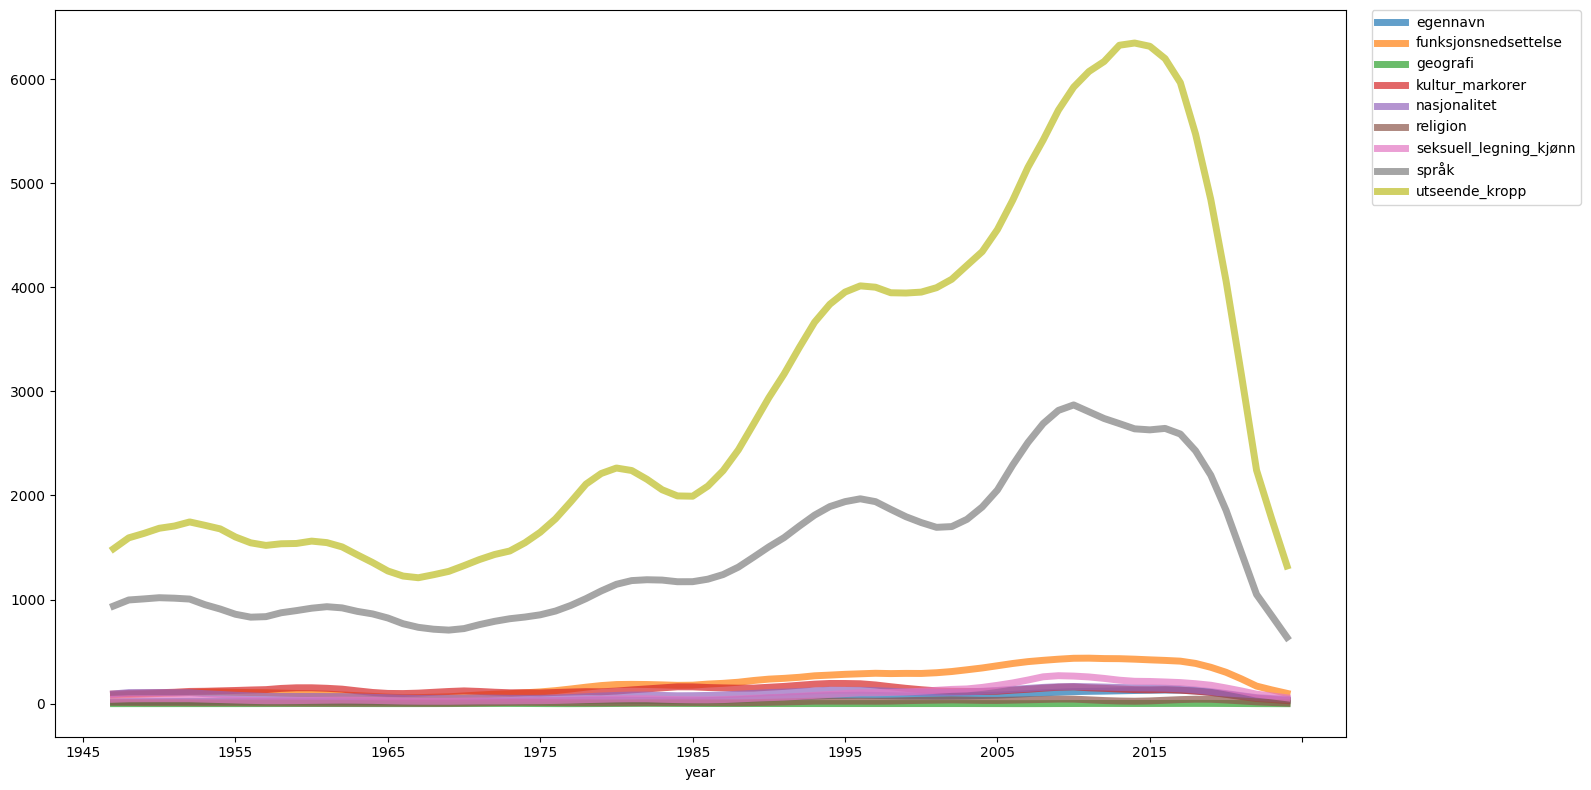

In [19]:
smooth_plot(smooth,lw=5,figsize=(16,8))

# Sjekk normalisering innen hver gruppe, hvor er det tettes

In [20]:
# grupper × år
group_norm_cohort = group_by_year.div(group_by_year.sum(axis=1), axis=0)

In [117]:
(group_norm_cohort.T)

group,egennavn,funksjonsnedsettelse,geografi,kultur_markorer,nasjonalitet,religion,seksuell_legning_kjønn,språk,utseende_kropp
year,,,,,,,,,
1945,0.003099,0.005461,0.000000,0.011501,0.008532,0.016842,0.004320,0.007174,0.005241
1946,0.002861,0.003519,0.015267,0.010510,0.017464,0.008421,0.007199,0.008747,0.006365
1947,0.004529,0.004369,0.000000,0.006643,0.011065,0.002807,0.005760,0.008018,0.006173
1948,0.003814,0.005764,0.015267,0.005751,0.011998,0.003509,0.005472,0.007529,0.006580
1949,0.005959,0.006007,0.000000,0.011600,0.013732,0.015439,0.008063,0.010231,0.008203
1950,0.008343,0.008373,0.007634,0.017549,0.025330,0.007719,0.010655,0.012356,0.009817
1951,0.003337,0.006978,0.007634,0.011898,0.009599,0.000702,0.005328,0.007529,0.006890
1952,0.005721,0.007827,0.022901,0.011699,0.011199,0.005614,0.005760,0.009120,0.008588
1953,0.004529,0.005643,0.000000,0.010113,0.006532,0.014035,0.004176,0.005005,0.005735


<Axes: xlabel='year'>

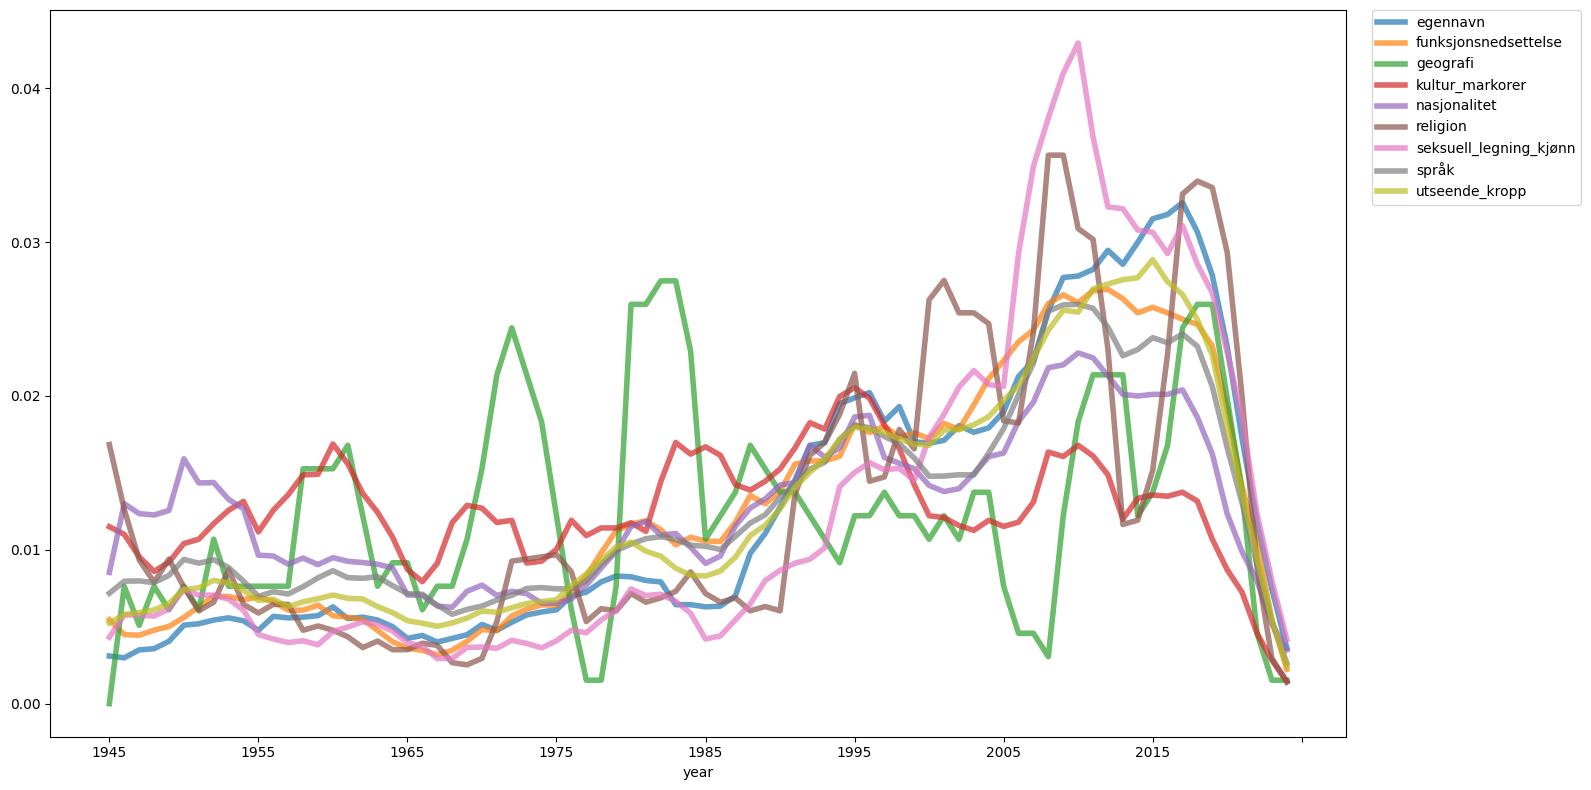

In [116]:
smooth_plot(group_norm_cohort.T)

# Sjekk gruppene mot hverandre pr.år

In [22]:
group_norm_year = group_by_year.div(group_by_year.sum(axis=0), axis=1)

<Axes: xlabel='year'>

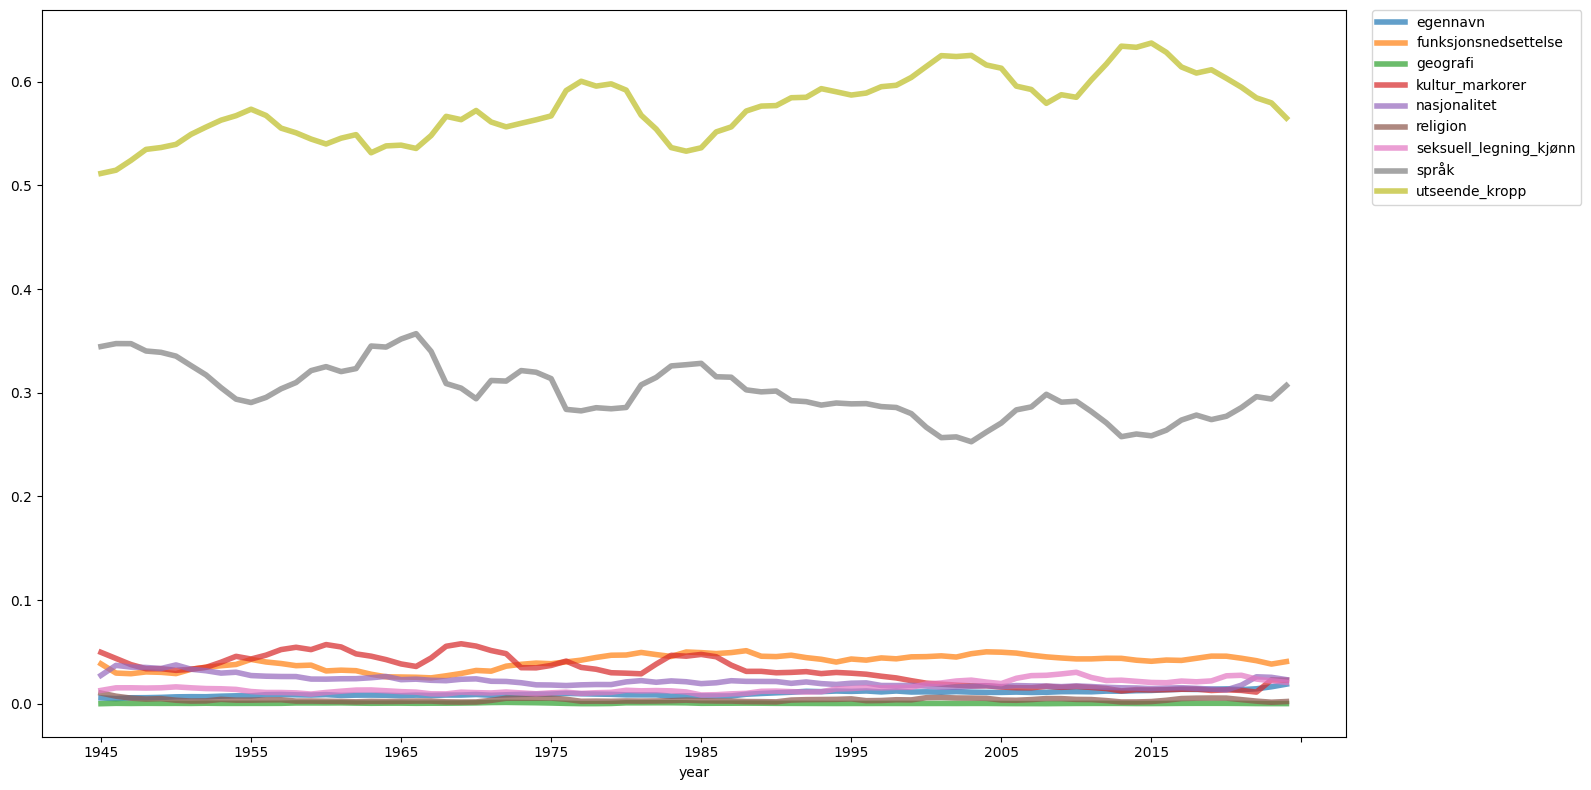

In [23]:
smooth_plot(group_norm_year.T)
    

<Axes: xlabel='year'>

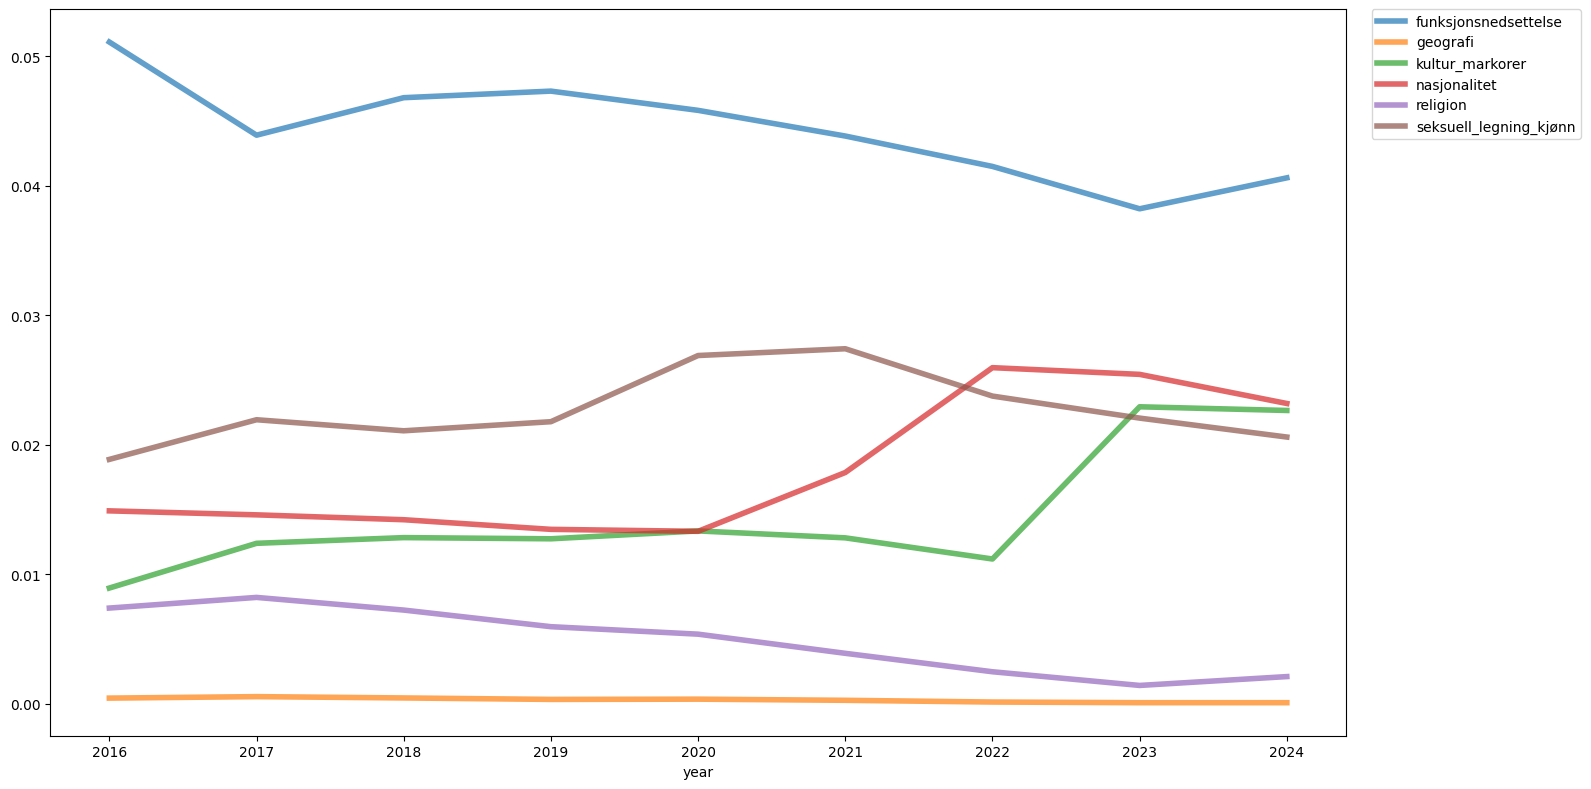

In [137]:
df = group_norm_year.loc[['funksjonsnedsettelse', 'geografi', 'kultur_markorer',
       'nasjonalitet', 'religion', 'seksuell_legning_kjønn']].T
smooth_plot(df[df.index > 2015])
    

<Axes: xlabel='year'>

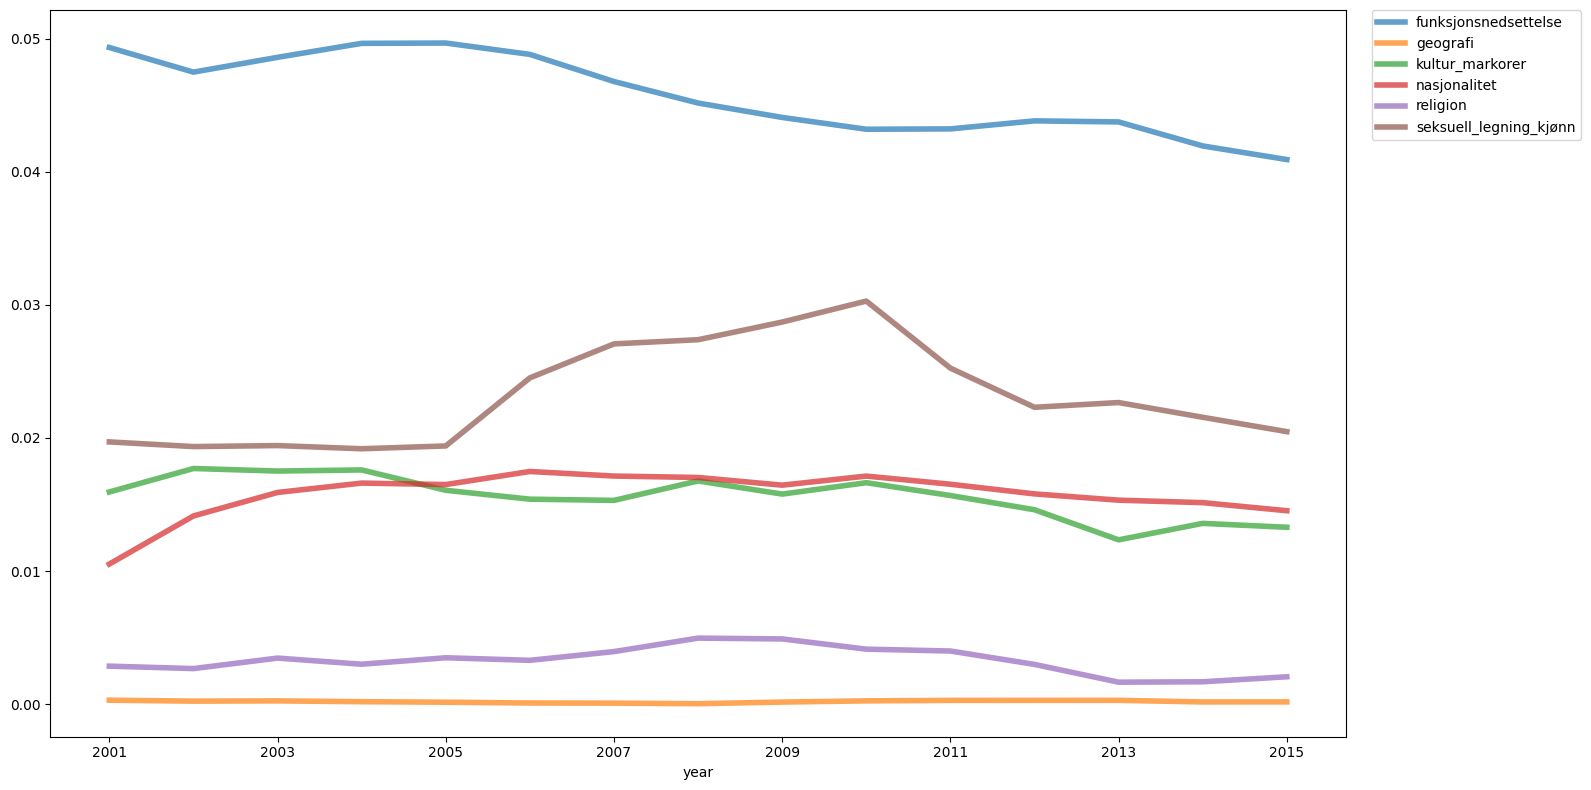

In [139]:
df = group_norm_year.loc[['funksjonsnedsettelse', 'geografi', 'kultur_markorer',
       'nasjonalitet', 'religion', 'seksuell_legning_kjønn']].T
smooth_plot(df[(df.index > 2000) & (df.index <= 2015)])
    

# Uthenting av markører

In [ ]:
# antall forekomster per ord og gruppe (du har counts + group)
word_totals = counts.drop(columns=["group"]).sum(axis=1)       # total frekvens per ord
word_totals = word_totals.to_frame("freq").assign(group=counts["group"])

In [33]:
def top_words_for_group(group, top=20, collection=""):
    cands = (
        word_totals
        .query("group == @group")
        .sort_values("freq", ascending=False)
        .head(top)
    )
    return cands[["freq"]]

In [29]:
group_by_year.index

Index(['egennavn', 'funksjonsnedsettelse', 'geografi', 'kultur_markorer',
       'nasjonalitet', 'religion', 'seksuell_legning_kjønn', 'språk',
       'utseende_kropp'],
      dtype='object', name='group')

In [34]:
top_words_for_group("funksjonsnedsettelse", 30)

,freq
word,
blind,11063.0
døv,3912.0
tunghørt,524.0
handikappet,287.0
albino,192.0
funksjonshemmet,123.0
svaksynt,92.0
klumpfot,71.0
dyslektiker,44.0


In [35]:
top_words_for_group("kultur_markorer", 30)

,freq
word,
indianer,5397.0
amerikaner,1305.0
araber,894.0
samisk,855.0
nordisk,512.0
afrikaner,260.0
europeer,254.0
innvandrer,243.0
keltisk,189.0


In [36]:
top_words_for_group("religion", 30)

,freq
word,
kristendom,671.0
islam,552.0
buddhisme,65.0
hinduisme,29.0
koptisk,28.0
jødedom,25.0
katolisisme,23.0
protestantisme,11.0
taoisme,11.0


In [86]:
sim_words("koptisk", limit=20)

,word,score
0,koptisk,1.000000
1,græft,0.796472
2,armenisk,0.783493
3,buddhistisk,0.763890
4,chaldæisk,0.749734
5,syrisk,0.748240
6,latinst,0.746956
7,hinduisk,0.732870
8,gammel-norsk,0.719789
9,jonisk,0.717015


In [87]:

def build_graph(word_groups, top=20, min_score=0.5):
    G = nx.Graph()

    for group, seeds in word_groups.items():
        for w in seeds:
            try:
                df = sim_words(w, limit=top)
                #print(w, len(df))
            except:
                continue

            for word, row in df.iterrows():
                score = row["score"]
                word = row["word"]
                if score < min_score:
                    continue

                G.add_edge(w, word, weight=score)
                G.nodes[w]["group"] = group

    return G


In [79]:
G = build_graph(word_groups, top=30)

In [89]:
#G.nodes()

In [80]:
import networkx.algorithms.community as nxcom

clusters = nxcom.louvain_communities(G, weight="weight")

In [91]:
#clusters

In [112]:
df = sim_words("trans")

In [113]:
df

,word,score
0,trans,1.000000
1,anal,0.830445
2,mapping,0.825284
3,gain,0.822817
4,tyristor,0.822494
5,avspaltning,0.817302
6,satsvis,0.816271
7,parallellkopling,0.814413
8,USB,0.811895
9,transceiver,0.808141


In [98]:
df.columns

Index(['word', 'score'], dtype='object')

In [103]:
def expand_group(seeds, top=20, min_score=0.55):
    expanded = set(seeds)

    for w in seeds:
        df = sim_words(w, limit=top)
        #print(w, df.columns)
        expanded |= set(df[df.score > min_score].word)

    return expanded

In [114]:
res = {x: expand_group(word_groups[x], min_score=0.8) for x in word_groups}

In [108]:
res

{'funksjonsnedsettelse': {'Bohemian',
  'albino',
  'authenticity',
  'autisme',
  'autistisk',
  'bevegelseshemmet',
  'blind',
  'diathesis',
  'dyslektiker',
  'døv',
  'enema',
  'epileptiker',
  'funksjonshemmet',
  'handikappet',
  'hørselshemmet',
  'injudicious',
  'klumpfot',
  'lubberly',
  'minstrelsy',
  'psykisk utviklingshemmet',
  'rullestolbruker',
  'svaksynt',
  'tunghørt'},
 'utseende_kropp': {'Bytta',
  'Fura',
  'Tume',
  'Tunna',
  'blaut',
  'breid',
  'drusteleg',
  'dumba',
  'fyk',
  'humla',
  'høy',
  'innvertes',
  'kraftig',
  'lav',
  'overvektig',
  'sekk',
  'skiten',
  'skøyta',
  'stærk',
  'tjukk',
  'tykk',
  'tynn',
  'undervektig',
  'ysma',
  'ækra',
  'ørliten',
  'øyk'},
 'seksuell_legning_kjønn': {'Verb',
  'aseksuell',
  'bi',
  'bifil',
  'careless',
  'childish',
  'clumsy',
  'cursed',
  'dismal',
  'fascinating',
  'heartless',
  'homofil',
  'homse',
  'intrans',
  'lesbe',
  'lesbisk',
  'loathsome',
  'mischievous',
  'monstrous',
  'n

In [115]:
res

{'funksjonsnedsettelse': {'ADHD',
  'ASD',
  'Abigael',
  'Awan',
  'Blikø',
  'CARLSEN',
  'Duvold',
  'Eikje',
  'Haefs',
  'Hallandvik',
  'Hjartåker',
  'Huusmand',
  'Jægersborg',
  'Jødal',
  'Jørre',
  'Krampe',
  'Lansky',
  'Mauk',
  'Modellstrikker',
  'Olie',
  'Rydving',
  'Sletbakk',
  'Stavelse',
  'Testikkel',
  'Vikhagen',
  'Waterton',
  'afasi',
  'affektiv',
  'albino',
  'aldersavhengig',
  'alkoholiker',
  'atferdsforstyrrelser',
  'atferdsvansker',
  'autisme',
  'autist',
  'autistisk',
  'avholdsmann',
  'belastningssykdommer',
  'bevegelseshemmet',
  'blind',
  'blodkreft',
  'bortskjemt',
  'brannkonstabel',
  'colostomi',
  'demens',
  'depressiv',
  'diskusjonsoppgaver',
  'dysleksi',
  'dyslektiker',
  'døv',
  'epilepsi',
  'epileptiker',
  'faryngitt',
  'feberkramper',
  'fjellkar',
  'flatlus',
  'foreldreløs',
  'forrykt',
  'fortapt',
  'frekkas',
  'frikveld',
  'fruktsommelig',
  'funksjonshemmet',
  'funksjonsnedsettelser',
  'gal',
  'giktfeber',
